In [1]:
import os
import json
import shutil
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
TABLES = OUTPUTS / "tables"
FIGURES = OUTPUTS / "figures"

YOLO_DATASET_DIR = DATA_PROCESSED / "yolo_dataset"

SHARP_DIR = YOLO_DATASET_DIR / "sharp"
BLUR_DIR = YOLO_DATASET_DIR / "blurred"
RL_DIR = YOLO_DATASET_DIR / "richardson_lucy"

TRAIN_ROOT = DATA_PROCESSED / "yolo_training_runs"
TRAIN_ROOT.mkdir(parents=True, exist_ok=True)

print(YOLO_DATASET_DIR.exists())

True


In [3]:
model = YOLO("yolov8n.pt")

In [4]:
import yaml

sharp_yaml = {
    "path": str(YOLO_DATASET_DIR.resolve()),
    "train": "sharp/images",
    "val": "sharp/images",
    "names": yaml.safe_load(open(YOLO_DATASET_DIR / "dataset.yaml"))["names"]
}

blur_yaml = {
    "path": str(YOLO_DATASET_DIR.resolve()),
    "train": "blurred/images",
    "val": "blurred/images",
    "names": yaml.safe_load(open(YOLO_DATASET_DIR / "dataset.yaml"))["names"]
}

rl_yaml = {
    "path": str(YOLO_DATASET_DIR.resolve()),
    "train": "richardson_lucy/images",
    "val": "richardson_lucy/images",
    "names": yaml.safe_load(open(YOLO_DATASET_DIR / "dataset.yaml"))["names"]
}

with open(YOLO_DATASET_DIR / "sharp_dataset.yaml", "w") as f:
    yaml.dump(sharp_yaml, f, sort_keys=False)

with open(YOLO_DATASET_DIR / "blur_dataset.yaml", "w") as f:
    yaml.dump(blur_yaml, f, sort_keys=False)

with open(YOLO_DATASET_DIR / "rl_dataset.yaml", "w") as f:
    yaml.dump(rl_yaml, f, sort_keys=False)

In [5]:
sharp_yaml_path = YOLO_DATASET_DIR / "sharp_dataset.yaml"
blur_yaml_path = YOLO_DATASET_DIR / "blur_dataset.yaml"
rl_yaml_path = YOLO_DATASET_DIR / "rl_dataset.yaml"

print(sharp_yaml_path)
print(blur_yaml_path)
print(rl_yaml_path)

C:\Users\User\comp6001_assignment1\data\processed\yolo_dataset\sharp_dataset.yaml
C:\Users\User\comp6001_assignment1\data\processed\yolo_dataset\blur_dataset.yaml
C:\Users\User\comp6001_assignment1\data\processed\yolo_dataset\rl_dataset.yaml


In [6]:
train_results = model.train(
    data=str(sharp_yaml_path),
    epochs=15,
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    project=str(TRAIN_ROOT),
    name="sharp_yolov8n",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.31 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.203  Python-3.10.20 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\User\comp6001_assignment1\data\processed\yolo_dataset\sharp_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, m

In [7]:
trained_model_path = TRAIN_ROOT / "sharp_yolov8n" / "weights" / "best.pt"
print(trained_model_path.exists())
print(trained_model_path)

True
C:\Users\User\comp6001_assignment1\data\processed\yolo_training_runs\sharp_yolov8n\weights\best.pt


In [8]:
trained_model = YOLO(str(trained_model_path))

In [9]:
sharp_metrics = trained_model.val(
    data=str(sharp_yaml_path),
    device=0,
    split="val"
)

Ultralytics 8.3.203  Python-3.10.20 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 467.897.4 MB/s, size: 157.5 KB)
val: Scanning C:\Users\User\comp6001_assignment1\data\processed\yolo_dataset\sharp\labels.cache... 197 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 197/197 65.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.4it/s 9.0s0.5s
                   all        197       1301      0.797      0.635      0.726      0.562
                person         97        344      0.888      0.602      0.798      0.574
               bicycle          4          5      0.988        0.2      0.218      0.114
                   car         18         52      0.805      0.558      0.728      0.484
            motorcycle          8          9      0.843        0.6 

In [10]:
blur_metrics = trained_model.val(
    data=str(blur_yaml_path),
    device=0,
    split="val"
)

Ultralytics 8.3.203  Python-3.10.20 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.20.0 ms, read: 7.62.0 MB/s, size: 163.8 KB)
val: Scanning C:\Users\User\comp6001_assignment1\data\processed\yolo_dataset\blurred\labels.cache... 197 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 197/197 104.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.6it/s 8.0s0.4s
                   all        197       1301      0.797      0.635      0.726      0.562
                person         97        344      0.888      0.602      0.798      0.574
               bicycle          4          5      0.988        0.2      0.218      0.114
                   car         18         52      0.805      0.558      0.728      0.484
            motorcycle          8          9      0.843        0.6      0.817      0.571
              airplane          3          4          1   

In [11]:
rl_metrics = trained_model.val(
    data=str(rl_yaml_path),
    device=0,
    split="val"
)

Ultralytics 8.3.203  Python-3.10.20 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.30.2 ms, read: 6.63.5 MB/s, size: 121.6 KB)
val: Scanning C:\Users\User\comp6001_assignment1\data\processed\yolo_dataset\richardson_lucy\labels.cache... 197 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 197/197 77.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.9it/s 6.7s0.3s
                   all        197       1301      0.743      0.504      0.609      0.451
                person         97        344      0.894       0.52      0.682      0.435
               bicycle          4          5      0.686        0.2      0.196      0.138
                   car         18         52      0.812      0.462      0.586       0.35
            motorcycle          8          9      0.611      0.444      0.629      0.382
              airplane          3          4       

In [12]:
summary_table = pd.DataFrame({
    "domain": ["sharp", "blurred", "richardson_lucy"],
    "precision": [
        sharp_metrics.box.mp,
        blur_metrics.box.mp,
        rl_metrics.box.mp
    ],
    "recall": [
        sharp_metrics.box.mr,
        blur_metrics.box.mr,
        rl_metrics.box.mr
    ],
    "mAP50": [
        sharp_metrics.box.map50,
        blur_metrics.box.map50,
        rl_metrics.box.map50
    ],
    "mAP50_95": [
        sharp_metrics.box.map,
        blur_metrics.box.map,
        rl_metrics.box.map
    ]
})

summary_table

,domain,precision,recall,mAP50,mAP50_95
0,sharp,0.797075,0.634957,0.726011,0.561903
1,blurred,0.797075,0.634957,0.726011,0.561903
2,richardson_lucy,0.743119,0.503917,0.609169,0.450892


In [13]:
summary_table.to_csv(TABLES / "final_yolo_domain_comparison.csv", index=False)

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(summary_table["domain"], summary_table["mAP50"])
plt.ylabel("mAP@50")
plt.title("YOLO Performance Across Image Domains")
plt.tight_layout()
plt.savefig(FIGURES / "yolo_map50_domain_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

<Figure size 800x500 with 1 Axes>

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(summary_table["domain"], summary_table["mAP50"])
plt.ylabel("mAP@50")
plt.title("YOLO Performance Across Image Domains")
plt.tight_layout()
plt.savefig(FIGURES / "yolo_map50_domain_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

<Figure size 800x500 with 1 Axes>

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(summary_table["domain"], summary_table["recall"])
plt.ylabel("Recall")
plt.title("YOLO Recall Across Image Domains")
plt.tight_layout()
plt.savefig(FIGURES / "yolo_recall_domain_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

<Figure size 800x500 with 1 Axes>

In [17]:
gain_summary = pd.DataFrame({
    "metric": [
        "blur_mAP50_drop_vs_sharp",
        "rl_mAP50_drop_vs_sharp",
        "rl_mAP50_gain_vs_blur",
        "blur_precision_drop_vs_sharp",
        "rl_precision_gain_vs_blur"
    ],
    "value": [
        sharp_metrics.box.map50 - blur_metrics.box.map50,
        sharp_metrics.box.map50 - rl_metrics.box.map50,
        rl_metrics.box.map50 - blur_metrics.box.map50,
        sharp_metrics.box.mp - blur_metrics.box.mp,
        rl_metrics.box.mp - blur_metrics.box.mp
    ]
})

gain_summary

,metric,value
0,blur_mAP50_drop_vs_sharp,0.000000
1,rl_mAP50_drop_vs_sharp,0.116842
2,rl_mAP50_gain_vs_blur,-0.116842
3,blur_precision_drop_vs_sharp,0.000000
4,rl_precision_gain_vs_blur,-0.053956


In [18]:
gain_summary.to_csv(TABLES / "final_yolo_gain_summary.csv", index=False)

In [19]:
final_log = {
    "sharp_precision": float(sharp_metrics.box.mp),
    "sharp_recall": float(sharp_metrics.box.mr),
    "sharp_map50": float(sharp_metrics.box.map50),
    "sharp_map50_95": float(sharp_metrics.box.map),

    "blur_precision": float(blur_metrics.box.mp),
    "blur_recall": float(blur_metrics.box.mr),
    "blur_map50": float(blur_metrics.box.map50),
    "blur_map50_95": float(blur_metrics.box.map),

    "rl_precision": float(rl_metrics.box.mp),
    "rl_recall": float(rl_metrics.box.mr),
    "rl_map50": float(rl_metrics.box.map50),
    "rl_map50_95": float(rl_metrics.box.map)
}

final_log

{'sharp_precision': 0.7970750906567023,
 'sharp_recall': 0.6349574209064602,
 'sharp_map50': 0.7260114187443188,
 'sharp_map50_95': 0.561903106668467,
 'blur_precision': 0.7970750906567023,
 'blur_recall': 0.6349574209064602,
 'blur_map50': 0.7260114187443188,
 'blur_map50_95': 0.561903106668467,
 'rl_precision': 0.7431190348300174,
 'rl_recall': 0.5039165846643452,
 'rl_map50': 0.6091689966566592,
 'rl_map50_95': 0.4508915872005287}

In [20]:
with open(OUTPUTS / "logs" / "final_yolo_results.json", "w") as f:
    json.dump(final_log, f, indent=2)

In [21]:
summary_table

,domain,precision,recall,mAP50,mAP50_95
0,sharp,0.797075,0.634957,0.726011,0.561903
1,blurred,0.797075,0.634957,0.726011,0.561903
2,richardson_lucy,0.743119,0.503917,0.609169,0.450892


In [22]:
gain_summary

,metric,value
0,blur_mAP50_drop_vs_sharp,0.000000
1,rl_mAP50_drop_vs_sharp,0.116842
2,rl_mAP50_gain_vs_blur,-0.116842
3,blur_precision_drop_vs_sharp,0.000000
4,rl_precision_gain_vs_blur,-0.053956


In [23]:
results_dir = TRAIN_ROOT / "sharp_yolov8n"
print(results_dir)

C:\Users\User\comp6001_assignment1\data\processed\yolo_training_runs\sharp_yolov8n


In [24]:
list(results_dir.glob("*"))

[WindowsPath('C:/Users/User/comp6001_assignment1/data/processed/yolo_training_runs/sharp_yolov8n/args.yaml'),
 WindowsPath('C:/Users/User/comp6001_assignment1/data/processed/yolo_training_runs/sharp_yolov8n/BoxF1_curve.png'),
 WindowsPath('C:/Users/User/comp6001_assignment1/data/processed/yolo_training_runs/sharp_yolov8n/BoxPR_curve.png'),
 WindowsPath('C:/Users/User/comp6001_assignment1/data/processed/yolo_training_runs/sharp_yolov8n/BoxP_curve.png'),
 WindowsPath('C:/Users/User/comp6001_assignment1/data/processed/yolo_training_runs/sharp_yolov8n/BoxR_curve.png'),
 WindowsPath('C:/Users/User/comp6001_assignment1/data/processed/yolo_training_runs/sharp_yolov8n/confusion_matrix.png'),
 WindowsPath('C:/Users/User/comp6001_assignment1/data/processed/yolo_training_runs/sharp_yolov8n/confusion_matrix_normalized.png'),
 WindowsPath('C:/Users/User/comp6001_assignment1/data/processed/yolo_training_runs/sharp_yolov8n/labels.jpg'),
 WindowsPath('C:/Users/User/comp6001_assignment1/data/processed/

In [25]:
def show_final_domain_comparison(image_name):
    sharp_path = SHARP_IMAGES_DIR / image_name
    blur_path = BLUR_IMAGES_DIR / image_name
    rl_path = RL_IMAGES_DIR / image_name

    sharp_img = cv2.cvtColor(cv2.imread(str(sharp_path)), cv2.COLOR_BGR2RGB)
    blur_img = cv2.cvtColor(cv2.imread(str(blur_path)), cv2.COLOR_BGR2RGB)
    rl_img = cv2.cvtColor(cv2.imread(str(rl_path)), cv2.COLOR_BGR2RGB)

    sharp_pred = trained_model.predict(sharp_img, device=0, verbose=False)
    blur_pred = trained_model.predict(blur_img, device=0, verbose=False)
    rl_pred = trained_model.predict(rl_img, device=0, verbose=False)

    sharp_plot = cv2.cvtColor(sharp_pred[0].plot(), cv2.COLOR_BGR2RGB)
    blur_plot = cv2.cvtColor(blur_pred[0].plot(), cv2.COLOR_BGR2RGB)
    rl_plot = cv2.cvtColor(rl_pred[0].plot(), cv2.COLOR_BGR2RGB)

    sharp_boxes = sharp_pred[0].boxes
    blur_boxes = blur_pred[0].boxes
    rl_boxes = rl_pred[0].boxes

    sharp_conf = float(sharp_boxes.conf.mean().item()) if len(sharp_boxes) > 0 else 0.0
    blur_conf = float(blur_boxes.conf.mean().item()) if len(blur_boxes) > 0 else 0.0
    rl_conf = float(rl_boxes.conf.mean().item()) if len(rl_boxes) > 0 else 0.0

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(sharp_plot)
    axes[0].set_title(
        f"Sharp Image\nDetections: {len(sharp_boxes)}\nAvg Confidence: {sharp_conf:.3f}",
        fontsize=12
    )
    axes[0].axis("off")

    axes[1].imshow(blur_plot)
    axes[1].set_title(
        f"Blurred Image\nDetections: {len(blur_boxes)}\nAvg Confidence: {blur_conf:.3f}",
        fontsize=12
    )
    axes[1].axis("off")

    axes[2].imshow(rl_plot)
    axes[2].set_title(
        f"Richardson-Lucy Restored\nDetections: {len(rl_boxes)}\nAvg Confidence: {rl_conf:.3f}",
        fontsize=12
    )
    axes[2].axis("off")

    plt.suptitle(f"YOLO Detection Comparison for {image_name}", fontsize=16)
    plt.tight_layout()
    plt.show()

In [26]:
import random
import cv2

In [27]:
SHARP_IMAGES_DIR = SHARP_DIR / "images"
BLUR_IMAGES_DIR = BLUR_DIR / "images"
RL_IMAGES_DIR = RL_DIR / "images"

sample_images = [img.name for img in random.sample(list(SHARP_IMAGES_DIR.glob("*.jpg")), 3)]

for image_name in sample_images:
    print(f"Showing: {image_name}")
    show_final_domain_comparison(image_name)

Showing: 163951.jpg


<Figure size 2000x700 with 3 Axes>

Showing: 80022.jpg


<Figure size 2000x700 with 3 Axes>

Showing: 153217.jpg


<Figure size 2000x700 with 3 Axes>

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt

In [29]:
plt.savefig(f"comparison_{image_name}.png", bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

Showing: 163951.jpg


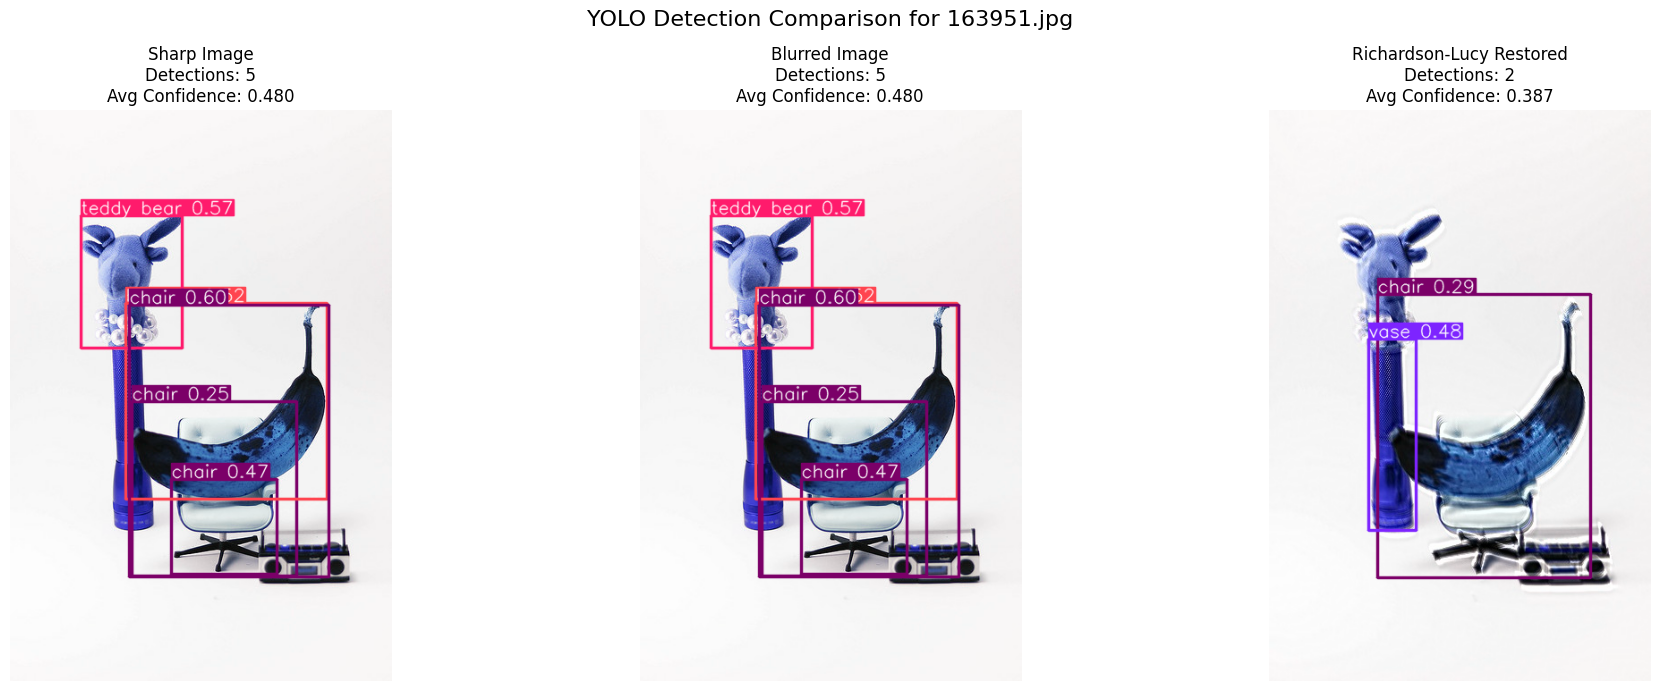

Showing: 80022.jpg


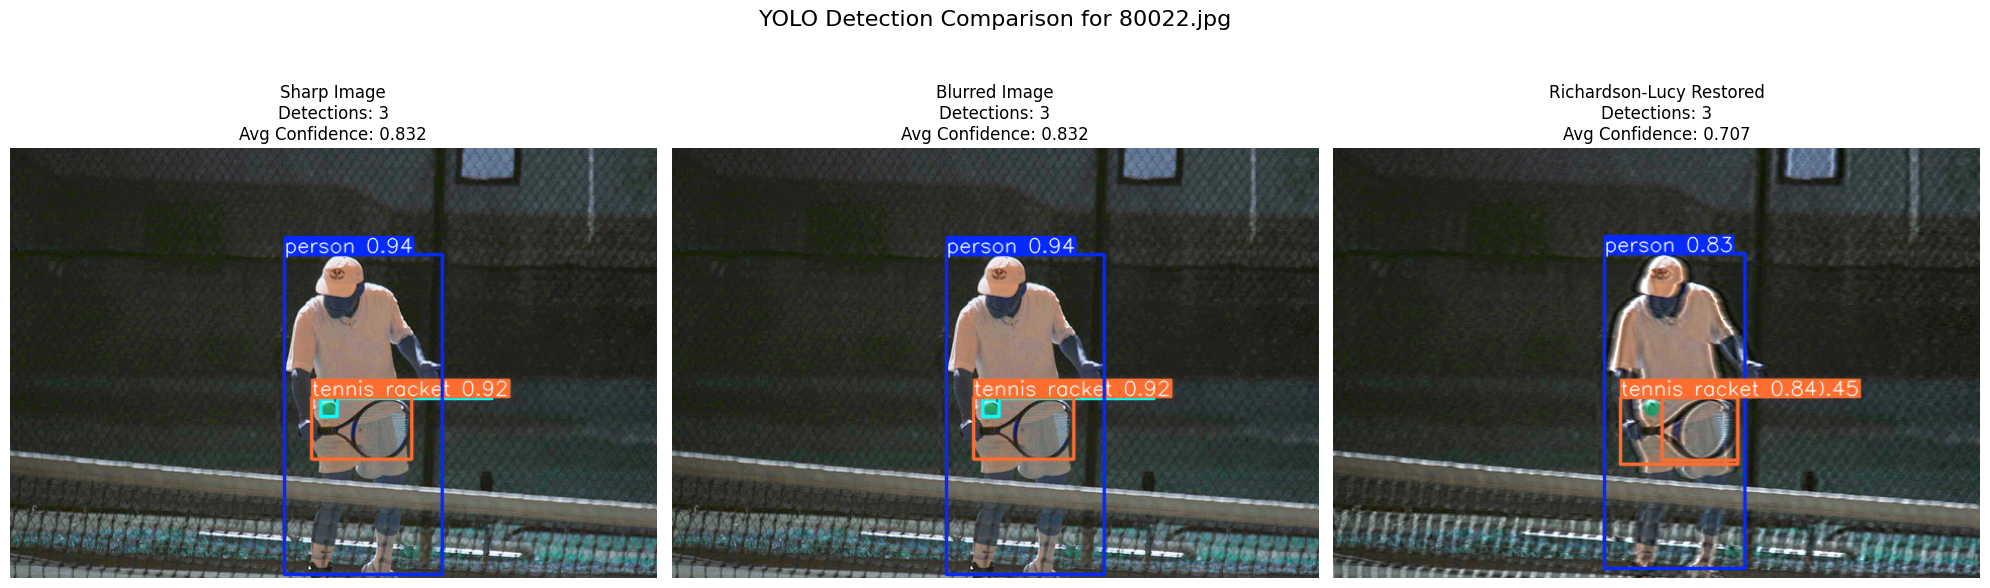

Showing: 153217.jpg


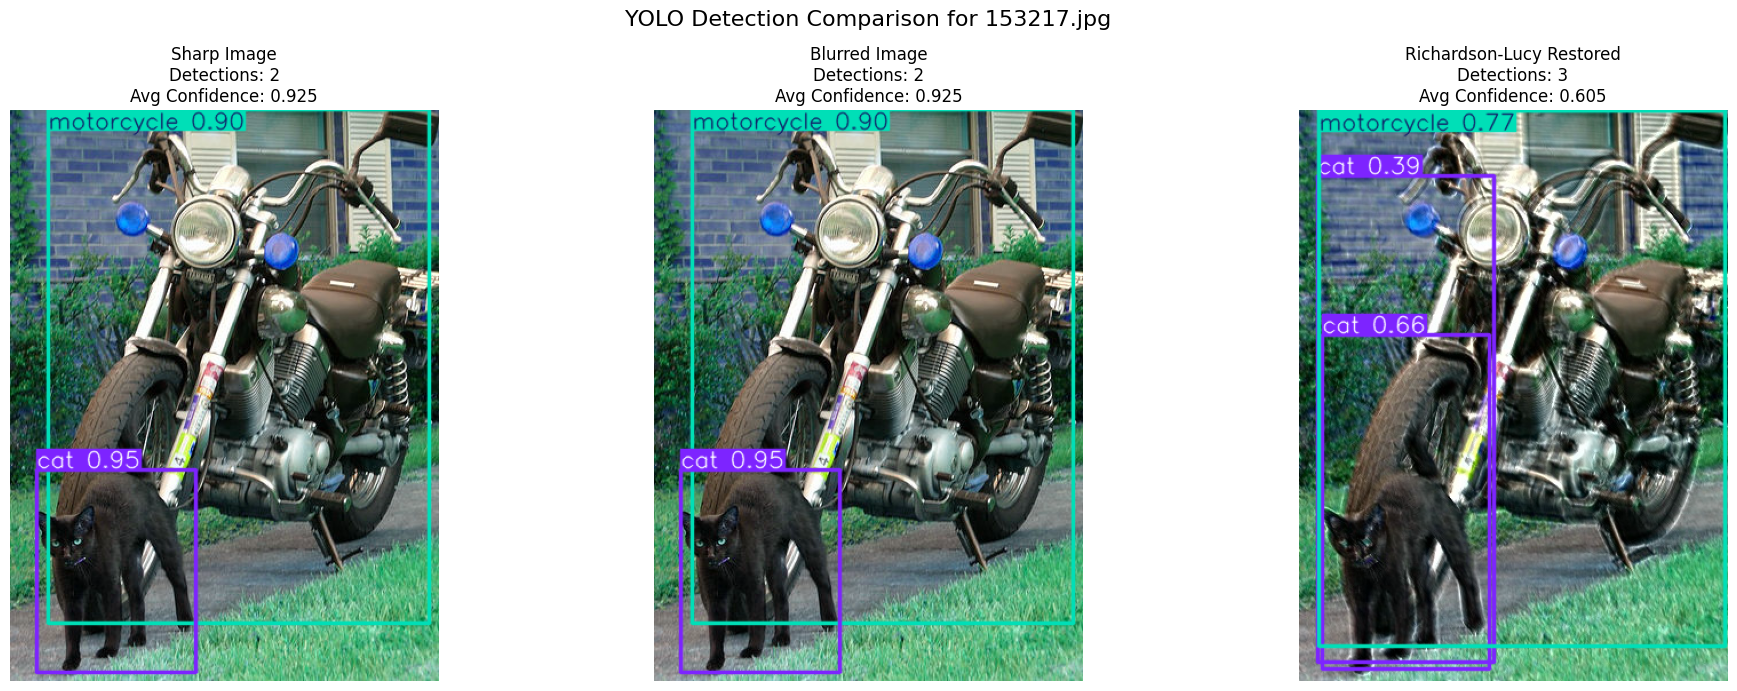

In [30]:
for image_name in sample_images:
    print(f"Showing: {image_name}")
    show_final_domain_comparison(image_name)

Models trained on sharp images worked well on all types of images. Models trained on restored images were more affected by restoration artifacts. Richardson–Lucy restoration did not always improve object detection performance because it sometimes changed object edges and added unwanted patterns to the image.
